<a href="https://colab.research.google.com/github/ARCILAEDNA/Spint7-Final-Project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
# Cantidad de valores nulos
print (users.isna().sum())
# Proporción de valores nulos
print (users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
# Cantidad de valores nulos
print (usage.isna().sum())
# Proporción de valores nulos
print (usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**:
 - "churn_date" en users tiene **más del 80% de nulos**, esta columan se **ignora o elimina**.  
 - "city" tiene **el 11.72% de nulos**, se **investiga para imputar o dejar como nulos**.
 - "duration" y "length" tienen **mas del 40% de nulos** se **investiga para imputar**.
 - "date" en usage tiene datos ausentes **menor al 5%**,se puede hacer una **simple de imputación o dejar como nulos**.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users["age"].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
usage[["duration", "length"]].describe()

,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000


- Las columnas 'id' y 'user_id' aunque se identifican como numéricas, no describen una característica medible del cliente, por lo que no es recomendable hacer cálculos estadísticos en estas columnas.

- La columna 'age' de users, tiene un promedio de 33.74 pero una desviación estándar de 1233.23 y un mínimo de -999 lo que sugiere un sentinel corrupto **requiere evaluación e imputación**

- La distribución de los datos en las columnas 'duration' y 'length' sugieren un sesgo a la derecha, ya que los promedios son mas altos que las medianas. Ambas columnas tienen mâximos particularmente altos, es necesario evaluar estos valores para estar seguros que no se trata de outliers imposibles.


In [ ]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]
columnas_user.describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene 3531 datos (469 faltantes), 7 ciudades diferentes y únicas, la que más clientes registra es Bogotá, con una frecuencia de 808.
- La columna `plan` tiene 4000 datos, 2 planes diferentes y únicos, el plan más adqirido por los clientes es el básico con una frecuencia de 2595.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 40000 datos, 2 tipos diferentes y unicos (texto y llamada), el mas usado es el texto con una frecuencia de 22093.

---
✍️ **Comentario**:

**Valores inválidos o sentinels**  
- Se encontrarion valores inválidos o sentinels en la columna age(-999):
  Estos se reemplazan por la mediana de la columna, ya que la media está distorsionada por este valor extremo
  
- En city, se encontró el sentinel "?":
  Estos se reemplazan por valores nulos (pd.NA)

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [ ]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se registran 4000 datos en diferentes años, incluyendo 40 registros en 2026, esto sugiere un error, porque los datos fueron guardados en 2024, es decir que para esa época, el año 2026 no estaba en curso.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, tenemos una cantidad de datos robusta de 39950 registros en un solo año: 2024. Evaluaremos los 50 datos que faltan.
Basaremos el análisis en estas fechas.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
-Existen 40 registros en el año 2026 en reg_date de la tabla users. Esta es una fecha imposible dado que los datos fueron guardados en 2024. Como no podemos confiar en estos valores ni corregirlos, la recomendación es eliminar esas 40 filas.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()


565

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[(users['reg_date'].dt.year== 2026) ,'reg_date']=pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending= False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending= False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los nulos en `duration` y `length` dependen completamente de la columna 'type', lo cual tiene sentido porque la duraciôn estâ asociada con las llamadas y la longitud con los textos. Se miden cosas diferentes. Son MAR por lo tanto se dejan como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text','is_call','duration']].agg('sum').reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg= usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call':'cant_llamadas', 'duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'],how= 'left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas=user_profile[['cant_mensajes','cant_llamadas','cant_minutos_llamada']].fillna(0)
user_age=user_profile['age']
col_num=pd.concat([columnas_numericas, user_age], axis=1)
col_num.describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225,48.122250
std,2.359738,2.145139,18.169564,17.690408
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.107500,33.000000
50%,5.000000,4.000000,19.780000,47.000000
75%,7.000000,6.000000,31.412500,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True)* 100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

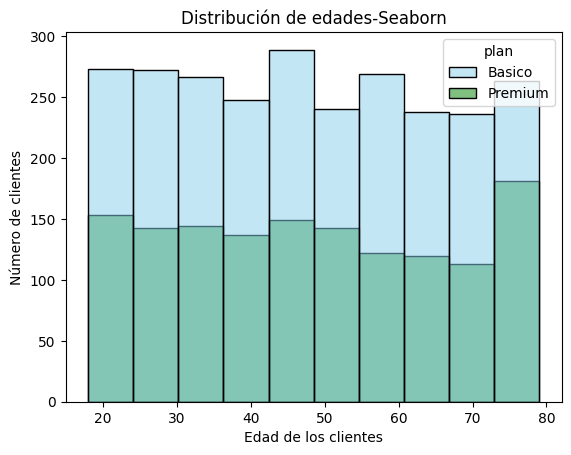

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan',bins=10, palette=['skyblue','green'], kde=False)
plt.xlabel('Edad de los clientes')
plt.ylabel('Número de clientes')
plt.title('Distribución de edades-Seaborn')
plt.show()

💡Insights:
- Distribución aproximadamente normal en el plan básico para todas las edades, no hay ningún rango de edad donde hayan muchos más o muchos menos clientes con este plan.
- La preferencia en todos los grupos de edad es claramente el plan básico. sin embargo, la diferencia en el número de clientes que prefieren básico sobre premium se reduce drásticamente en el rango de edades entre los 75 y 80 años.
- Se evidencia una pequeña baja en el número de clientes entre los 60 y 75 años tuanto para premium como para básico.

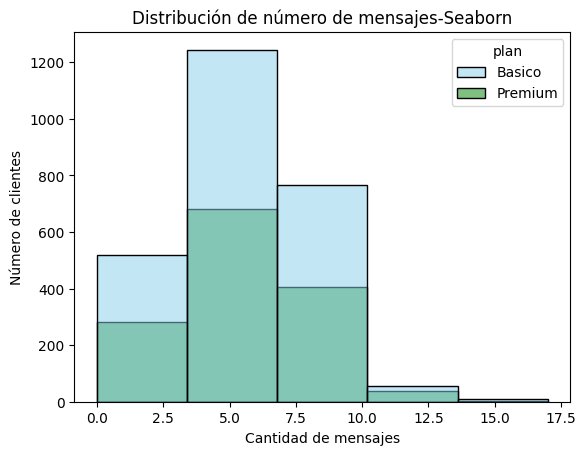

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=5, palette=['skyblue','green'], kde=False)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Número de clientes')
plt.title('Distribución de número de mensajes-Seaborn')
plt.show()

💡Insights:

- La mayoría de los clientes de ambos planes envía un número reducido de mensajes, principalmente entre 3.4 y 6.8 mensajes al mes.
- Entre 0 y 10.2 mensajes mensuales, el número de clientes del plan Básico es aproximadamente el doble que el del plan Premium. Sin embargo, entre los 10.2 y 13.6 mensajes mensuales, la cantidad de clientes Premium es muy similar a la de clientes del plan Básico.


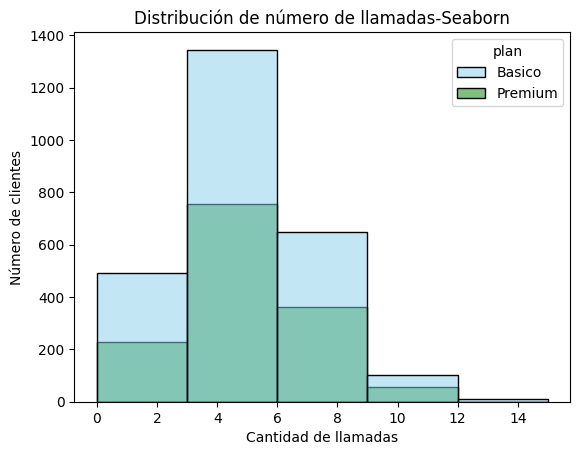

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=5, palette=['skyblue','green'], kde=False)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Número de clientes')
plt.title('Distribución de número de llamadas-Seaborn')
plt.show()


💡Insights:

- La mayoría de los clientes de ambos planes realiza un número reducido de llamadas, concentrándose principalmente entre 3,4 y 6,8 llamadas al mes.
- Aproximadamente, el doble de clientes del plan Básico realiza entre 0 y 10,2 llamadas al mes en comparación con los clientes del plan Premium que se encuentran en este mismo rango.
- A partir de 10,2 hasta 14 llamadas mensuales, el número de clientes disminuye drásticamente; sin embargo, la proporción entre clientes de ambos planes se mantiene similar.

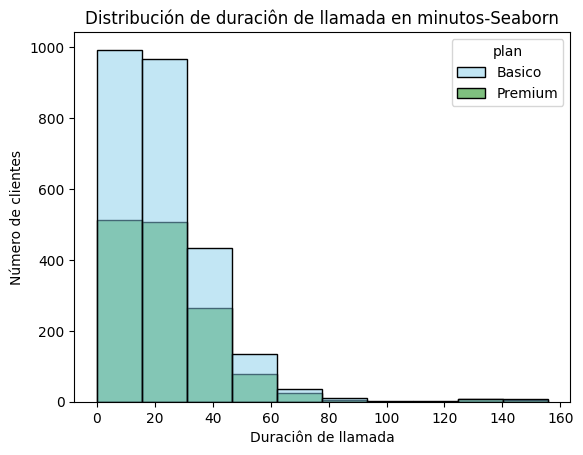

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=10, palette=['skyblue','green'], kde=False)
plt.xlabel('Duraciôn de llamada')
plt.ylabel('Número de clientes')
plt.title('Distribución de duraciôn de llamada en minutos-Seaborn')
plt.show()


💡Insights:
- La mayoría de los clientes, tanto del plan Básico como del Premium, realiza llamadas con una duración de entre 0 y 31,14 minutos.
- A partir de los 31,14 minutos, se observa una disminución significativa en el número de clientes que realizan llamadas de mayor duración en ambos planes.
- La proporción de clientes entre los planes Básico y Premium se mantiene relativamente constante a lo largo de los diferentes rangos de duración.
- La distribución de la duración de las llamadas presenta un sesgo hacia la derecha, debido a la presencia de pocos clientes con llamadas de duración considerablemente mayor. Entre 93,42 y 124,56 minutos parece no haber registros; posteriormente, la distribución vuelve a presentar algunos valores por encima de los 124,56 minutos, que podrían corresponder a valores atípicos (outliers).


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

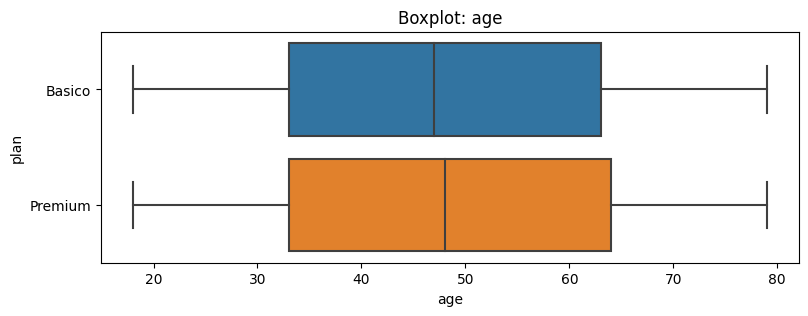

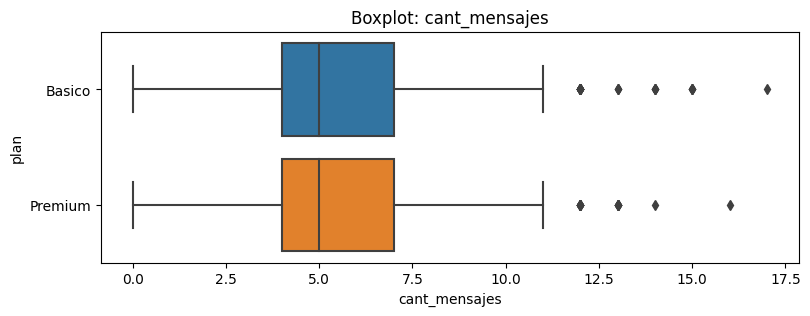

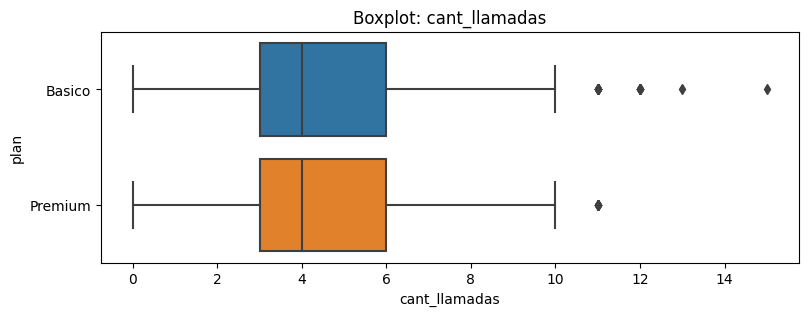

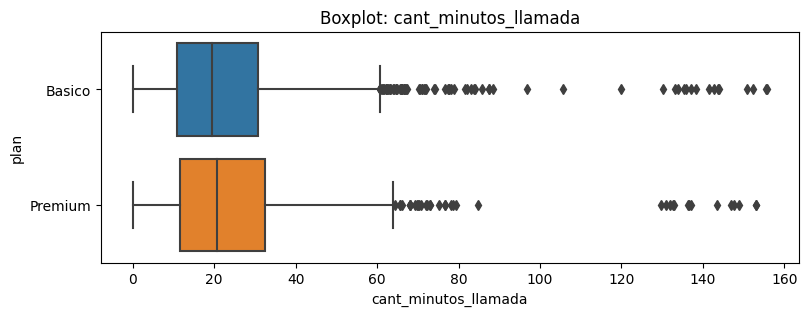

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(data=user_profile, x=col, y='plan')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: no presenta outliers
- cant_mensajes: presenta unos pocos outliers
- cant_llamadas: presenta unos pocos outliers
- cant_minutos_llamada: presenta bastantes outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1

    print(col, 'IQR:', IQR)

    upper= Q3+1.5*IQR
    lower= Q1-1.5*IQR
    print('Upper:', upper)
    display(user_profile[(user_profile[col]>upper)|(user_profile[col]<lower)])

cant_mensajes IQR: 3.0
Upper: 11.5


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
315,10315,Carlos,Lopez,30.0,MTY,2022-03-28 06:04:03.060765192,Basico,NaN,13.0,3.0,12.36
347,10347,Carlos,Garcia,77.0,Cali,2022-04-06 00:21:36.324081021,Basico,NaN,13.0,3.0,21.40
356,10356,Mateo,Garcia,42.0,CDMX,2022-04-08 11:30:17.554388598,Basico,NaN,12.0,5.0,59.48
384,10384,Sofia,Ramirez,35.0,CDMX,2022-04-16 03:30:39.159789948,Premium,NaN,12.0,3.0,13.05
456,10456,Mateo,Ramirez,47.0,CDMX,2022-05-05 20:40:09.002250564,Basico,"1,72653E+18",12.0,1.0,2.24
539,10539,Sofia,Ramirez,77.0,Cali,2022-05-28 14:06:55.903975994,Basico,NaN,14.0,5.0,8.66
591,10591,Ana,Gomez,25.0,NaN,2022-06-11 19:50:27.456864216,Basico,NaN,12.0,2.0,16.52
670,10670,Carlos,Torres,47.0,Bogotá,2022-07-03 11:00:02.700675170,Basico,NaN,12.0,3.0,19.13
903,10903,Carlos,Lopez,63.0,CDMX,2022-09-05 06:11:36.774193548,Premium,"1,72938E+18",12.0,3.0,8.89
908,10908,Mariana,Lopez,56.0,MTY,2022-09-06 15:03:06.346586648,Basico,NaN,14.0,3.0,12.50


cant_llamadas IQR: 3.0
Upper: 10.5


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
116,10116,Ana,Garcia,52.0,CDMX,2022-02-01 18:18:38.079519880,Basico,NaN,3.0,11.0,44.32
417,10417,Luis,Garcia,70.0,Bogotá,2022-04-25 04:22:30.337584396,Basico,NaN,4.0,12.0,26.42
777,10777,Sofia,Lopez,65.0,Cali,2022-08-01 18:09:59.549887472,Basico,NaN,4.0,12.0,55.28
778,10778,Mateo,Lopez,77.0,NaN,2022-08-02 00:44:17.464366092,Basico,NaN,8.0,11.0,32.13
862,10862,Luis,Ramirez,23.0,Bogotá,2022-08-25 00:45:22.280570144,Basico,NaN,4.0,15.0,78.11
1013,11013,Mateo,Lopez,65.0,CDMX,2022-10-05 09:04:27.366841712,Basico,NaN,4.0,11.0,60.83
1564,11564,Carlos,Lopez,41.0,CDMX,2023-03-05 06:02:58.244561144,Basico,NaN,8.0,11.0,30.17
1614,11614,Mateo,Garcia,73.0,Bogotá,2023-03-18 22:37:53.968492128,Basico,NaN,5.0,11.0,41.80
1912,11912,Mariana,Garcia,48.0,Medellín,2023-06-08 12:58:52.483120784,Premium,NaN,2.0,11.0,65.71
2013,12013,Mateo,Lopez,48.0,GDL,2023-07-06 04:43:01.845461368,Basico,NaN,2.0,12.0,65.55


cant_minutos_llamada IQR: 20.295
Upper: 61.8575


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
27,10027,Ana,Gomez,28.0,MTY,2022-01-08 09:26:03.690922730,Premium,NaN,8.0,7.0,84.77
85,10085,Carlos,Ramirez,65.0,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,6.0,5.0,152.36
93,10093,Ana,Torres,67.0,Medellín,2022-01-26 11:09:46.046511628,Basico,NaN,2.0,7.0,71.57
189,10189,Mariana,Torres,63.0,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,9.0,4.0,155.42
198,10198,Sofia,Gomez,58.0,Medellín,2022-02-24 05:11:07.066766692,Basico,"1,73033E+18",8.0,9.0,78.77
...,...,...,...,...,...,...,...,...,...,...,...
3920,13920,Mariana,Lopez,48.0,Bogotá,2024-12-09 08:50:24.756189056,Premium,NaN,4.0,5.0,132.72
3927,13927,Mariana,Lopez,18.0,GDL,2024-12-11 06:50:30.157539392,Basico,"1,72549E+18",8.0,4.0,135.96
3945,13945,Luis,Ramirez,30.0,Bogotá,2024-12-16 05:07:52.618154544,Basico,NaN,7.0,3.0,133.97
3953,13953,Mateo,Gomez,58.0,GDL,2024-12-18 09:42:15.933983504,Basico,NaN,0.0,7.0,155.69


In [ ]:
# comparar cant_llamadas y cant_minutos _llamadas para los posibles outliers(ex. >=115)
user_profile[user_profile['cant_minutos_llamada']>=115]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
85,10085,Carlos,Ramirez,65.0,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,6.0,5.0,152.36
189,10189,Mariana,Torres,63.0,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,9.0,4.0,155.42
216,10216,Ana,Garcia,75.0,GDL,2022-03-01 03:28:29.527381846,Premium,NaN,4.0,6.0,148.76
226,10226,Luis,Torres,26.0,GDL,2022-03-03 21:11:28.672168042,Basico,NaN,1.0,1.0,120.00
349,10349,Ana,Gomez,67.0,GDL,2022-04-06 13:30:12.153038260,Basico,NaN,6.0,7.0,150.92
372,10372,Ana,Gomez,49.0,MTY,2022-04-12 20:39:04.186046512,Basico,NaN,7.0,7.0,143.63
399,10399,Mateo,Gomez,70.0,CDMX,2022-04-20 06:05:07.876969242,Premium,NaN,5.0,4.0,136.24
484,10484,Ana,Gomez,45.0,Bogotá,2022-05-13 12:40:30.607651914,Premium,NaN,7.0,6.0,137.07
534,10534,Carlos,Lopez,63.0,CDMX,2022-05-27 05:15:26.331582896,Premium,NaN,3.0,4.0,153.06
585,10585,Ana,Gomez,68.0,GDL,2022-06-10 04:24:39.969992498,Premium,NaN,5.0,5.0,153.02


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



💡Insights:
- cant_mensajes: Se mantienen los datos, aunque estadísticamente el método del IQR los identifique como outliers. Esto se debe a que no representan errores en los datos, sino una variabilidad real en el comportamiento de los usuarios.
- cant_llamadas: Se mantienen los datos, aunque estadísticamente el método del IQR los identifique como outliers. Al igual que en cant_mensajes, estos valores reflejan una variabilidad real en el comportamiento de los usuarios y no errores de datos.
- cant_minutos_llamada: El valor máximo (155.69) es casi tres veces superior al límite superior (61.86), a diferencia de cant_mensajes y cant_llamadas, donde la diferencia es menor. Los outliers se distribuyen de manera similar entre ambos planes (2.54% en Básico vs. 3.06% en Premium), por lo que no parecen estar asociados a un plan específico. Además, al comparar la cantidad de llamadas con su duración en los registros identificados como posibles outliers, se observa que estos valores pueden explicarse por una variabilidad real en el comportamiento de los usuarios. Por lo tanto, se decide mantener estos datos.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


def grupo_usage (row):
    llamadas=row['cant_llamadas']
    mensajes=row['cant_mensajes']
    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en datos"
#Segmentaciôn bajo uso
    if llamadas<5 and mensajes<5:
            return 'Bajo uso'
#Segmentaciôn uso medio
    elif llamadas<10 and mensajes<10:
            return 'Uso medio'
#Segmentaciôn uso alto
    else:
        return 'Alto uso'
user_profile['grupo_uso']= user_profile.apply(grupo_usage, axis=1)
user_profile['grupo_uso'].value_counts()

Uso medio         2943
Bajo uso           778
Alto uso           278
Error en datos       1
Name: grupo_uso, dtype: int64

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def grupo_age (row):
    edad=row['age']
    if pd.isna(edad):
        return "Error en datos"

#Segmentaciôn joven
    if edad<30:
            return 'Joven'
#Segmentaciôn adulto
    elif edad<60:
            return 'Adulto'
#Segmentaciôn adulto mayor

    else:
        return 'Adulto Mayor'
user_profile['grupo_edad']= user_profile.apply(grupo_age, axis=1)
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

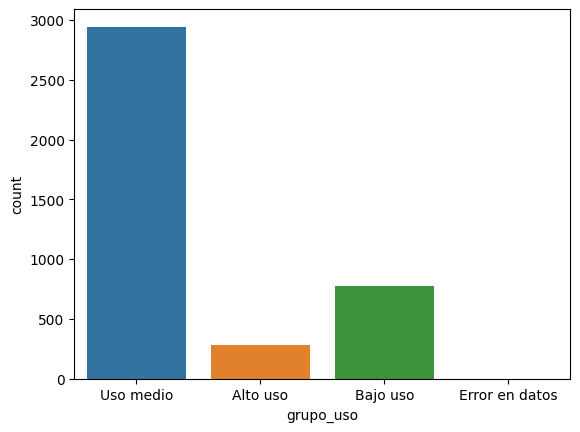

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.show()

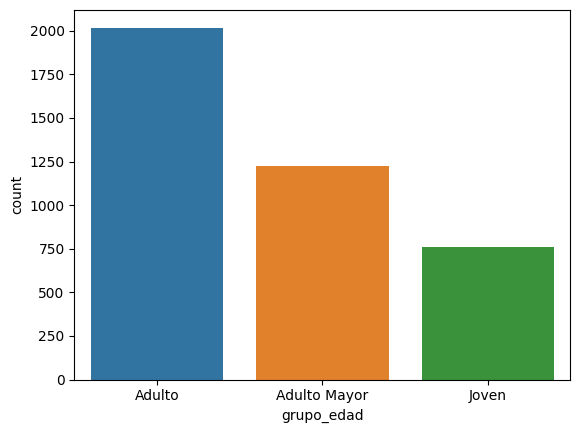

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- La columna 'churn_date' en users: presentaba más del 80% de valores nulos. Debido a que la mayoría de los registros no contienen información sobre la fecha de cancelación, esta variable tiene una alta proporción de datos faltantes y debe excluirse del análisis que requiera esta información.
- La columna 'city' en users: presentaba 469 valores nulos, equivalentes al 11,72% de los registros. Estos datos podrían afectar análisis geográficos, por lo que se conservaron como faltantes ya que no existe una fuente confiable para imputarlos. Adicionalmente 96 datos presentaban sentinels como "?" los cuales se remplazaron por valores nulos para evitar contaminaciôn en los câlculos, esto nos dio un total de 565 valores nulos para esta columna.
- Las columnas 'duration' y 'length': presentaban más del 40% de valores nulos. Antes de utilizarlas para analizar el comportamiento de las llamadas o mensajes, se determinô el origen de estos faltantes y se concluyô que estos nulos dependîan de la columna 'type'.
-La columna 'date' en usage: presenta menos del 5% de datos faltantes. Debido a su baja proporción, estos registros se mantuvieron como nulos para los câlculos y análisis.
La columna 'reg_date': presentaba 40 registros en una fecha imposible, estas fechas se convitiron a nulas, esta columna no se tuvo en cuenta para los anâlisis.
En general, los principales problemas identificados corresponden a valores faltantes, especialmente en variables relacionadas con cancelación, ubicación y características del uso.

🔍 **Segmentos por Edad**

Se definieron los siguientes grupos:

Joven: menores de 30 años.
Adulto: entre 30 y 59 años.
Adulto mayor: 60 años o más.

📊 **Segmentos por Nivel de Uso**

Los clientes también fueron clasificados según la cantidad de llamadas y mensajes realizados:

Bajo uso: menos de 5 llamadas y menos de 5 mensajes.
Uso medio: menos de 10 llamadas y menos de 10 mensajes.
Alto uso: 10 o más llamadas y 10 o más mensajes.

➡️ Esto sugiere que:
Por edad: predominan los adultos (~50%), seguidos por los adultos mayores (~31%) y los jóvenes (~19%).
Por nivel de uso: la mayoría de los clientes presenta uso medio (~73%), mientras que aproximadamente 19% tiene bajo uso y 7% alto uso.
Esto indica que la mayor parte de los clientes tiene un consumo moderado, pero existe un grupo de usuarios de alto consumo que puede representar una oportunidad comercial para ConnectaTel.

💡 **Recomendaciones**

- Mantener planes competitivos para el segmento de uso medio, que representa la mayoría de los clientes.
- Crear opciones de mayor capacidad o planes premium para usuarios de alto consumo, buscando aprovechar su mayor utilización.
- Diseñar estrategias de activación para clientes de bajo uso, con promociones o planes económicos que incentiven un mayor uso.
Se recomienda establecer controles para reducir la cantidad de valores faltantes en variables importantes como city, reg_date, date, duration y length. Una mejor calidad de datos permitirá realizar segmentaciones y análisis comerciales más precisos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---